In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import numpy as np
import tiktoken

from pathlib import Path

tokenizer = tiktoken.get_encoding("gpt2")

### 모델 설정

In [2]:
# GPT-2 모델 설정값
GPT_CONFIG_124M = {
    "vocab_size": 50257,    # 어휘사전 크기
    "context_length": 256,  # 문맥 길이
    "emb_dim": 768,         # 임베딩 차원
    "n_heads": 12,          # 어텐션 헤드 개수
    "n_layers": 12,         # 층 개수
    "drop_rate": 0.1,       # 드롭아웃 비율
    "qkv_bias": False       # 쿼리, 키, 값 계산을 위한 편향
}

In [3]:
# Multi Head Attention
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert (d_out % num_heads == 0), "d_out은 num_heads로 나누어 떨어져야 합니다."

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)    # Q = x @ W_query.T
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)      # K = x @ W_key.T 
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)    # V = x @ W_value.T 

        self.out_proj = nn.Linear(d_out, d_out)
        self.dropout = nn.Dropout(p=dropout)
        self.register_buffer("mask", torch.triu(torch.ones(context_length, context_length), diagonal=1))

    def forward(self, x):
        b, num_tokens, d_in = x.shape
        queries = self.W_query(x)
        keys = self.W_key(x)
        values = self.W_value(x)

        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)
        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)

        # (b, tokens, heads, head_dim) -> (b, heads, tokens, head_dim)
        queries = queries.transpose(1, 2) 
        keys = keys.transpose(1, 2)
        values = values.transpose(1, 2)

        # (b, heads, tokens, head_dim) @ (b, heads, head_dim, tokens) -> (b, heads, tokens, tokens)
        attn_scores = queries @ keys.transpose(2, 3)
        attn_scores.masked_fill_(self.mask.bool()[:num_tokens, :num_tokens], -torch.inf)
        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        # (b, heads, tokens, tokens) @ (b, heads, tokens, head_dim) -> T -> (b, tokens, heads, head_dim)
        context_vecs = (attn_weights @ values).transpose(1, 2)
        # (b, tokens, heads, head_dim) -> (b, tokens, d_out)
        context_vecs = context_vecs.contiguous().view(b, num_tokens, self.d_out)

        # head 간 정보를 섞는 단계
        context_vecs = self.out_proj(context_vecs)
        return context_vecs

In [4]:
# Layer Normalization
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        
        # y = \gamma \hat{x} + \beta
        return self.scale * norm_x + self.shift

In [5]:
# Feed Forward
# Self-Attention은 토큰 간 정보 교환(token mixing), FFN은 각 토큰 내부의 feature 변환(channel/feature mixing)을 담당한다.
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            nn.GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"])
        )

    def forward(self, x):
        return self.layers(x)

In [6]:
# Transformer Block
class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            dropout=cfg["drop_rate"],
            num_heads=cfg["n_heads"],
            qkv_bias=cfg["qkv_bias"]
        )
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(p=cfg["drop_rate"])

    def forward(self, x):
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)
        x = self.drop_shortcut(x)
        x = x + shortcut

        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut
        return x

In [7]:
# GPT Model
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])]
            )

        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape

        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))

        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

### 데이터 준비

In [9]:
# 데이터셋 로드 (소설 The Verdict)
file_path = Path("../ch02_working-with-text-data/the-verdict.txt")
with open(file_path, "r", encoding="utf-8") as file:
    text_data = file.read()

# 문자와 토큰 수를 확인
total_characters = len(text_data)
total_tokens = len(tokenizer.encode(text_data))
print(f"문자 수: {total_characters}")       # 문자 수: 20479
print(f"토큰 수: {total_tokens}")           # 토큰 수: 5145

문자 수: 20479
토큰 수: 5145


In [10]:
# Dataset
class GPTDatasetV1(Dataset):
    def __init__(self, txt, tokenizer, max_length, stride):
        self.input_ids = []
        self.target_ids = []

        token_ids = tokenizer.encode(txt)

        for i in range(0, len(token_ids) - max_length, stride):
            input_chunk = token_ids[i:i+max_length]
            target_chunk = token_ids[i+1:i+max_length+1]
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]

# DataLoader
def create_dataloader_v1(txt, batch_size=4, max_length=256, stride=128, shuffle=True, drop_last=True, num_workers=0):
    tokenizer = tiktoken.get_encoding("gpt2")
    dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=num_workers
    )
    return dataloader

### 훈련 루프에 부가 기능 추가하기

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): 

In [ ]:
# 데이터 로더를 준비, The Verdict를 로드
train_ratio = 0.90
split_idx = int(train_ratio * len(text_data))

torch.manual_seed(123)
train_loader = create_dataloader_v1(
    txt=text_data[:split_idx],
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0
)
val_loader = create_dataloader_v1(
    txt=text_data[split_idx:],
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0
)

print(len(train_loader))    # 9
print(len(val_loader))      # 1

9
1


In [13]:
n_epochs = 15
initial_lr = 0.0001
peak_lr = 0.01

total_steps = len(train_loader) * n_epochs
print(total_steps) # 135

warmup_steps = int(0.2 * total_steps)
print(warmup_steps) # 27

135
27


In [19]:
import math

optimizer = torch.optim.AdamW(
    # params: ParamsT,
    model.parameters(),
    # lr: float | Tensor = 0.001,
    # betas: tuple[float | Tensor, float | Tensor] = (0.9, 0.999),
    # eps: float = 1e-8,
    # weight_decay: float = 0.01,
    weight_decay=0.1,
    # amsgrad: bool = False,
    # *,
    # maximize: bool = False,
    # foreach: bool | None = None,
    # capturable: bool = False,
    # differentiable: bool = False,
    # fused: bool | None = None
    )

min_lr = 0.1 * initial_lr # 0.00001

lr_increment = (peak_lr - initial_lr) / warmup_steps

track_lrs = []
global_steps = -1

for epoch in range(n_epochs):
    for input_batch, target_batch in train_loader:
        optimizer.zero_grad()
        global_steps += 1

        if global_steps < warmup_steps:
            lr = initial_lr + lr_increment * global_steps
        else:
            progress = ((global_steps - warmup_steps) / (total_steps - warmup_steps))
            lr = min_lr + (peak_lr - min_lr) * 0.5 * (1 + math.cos(math.pi * progress))
        
        for param_group in optimizer.param_groups:
            param_group["lr"] = lr
        track_lrs.append(optimizer.param_groups[0]["lr"])

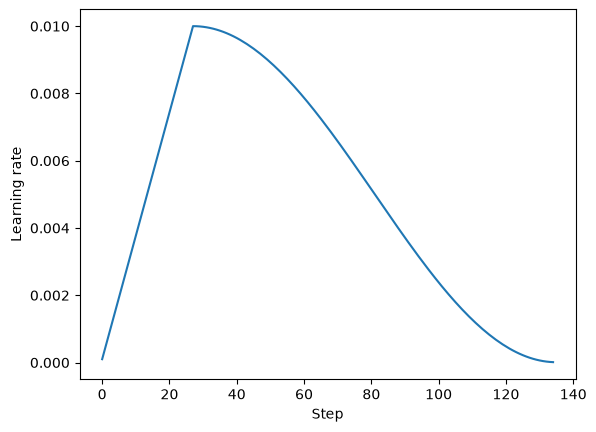

In [20]:
import matplotlib.pyplot as plt

plt.ylabel("Learning rate")
plt.xlabel("Step")
total_training_steps = len(train_loader) * n_epochs
plt.plot(range(total_training_steps), track_lrs)
plt.show()